# TASK 1: PROJECT OVERVIEW & KEY LEARNING OBJECTIVES

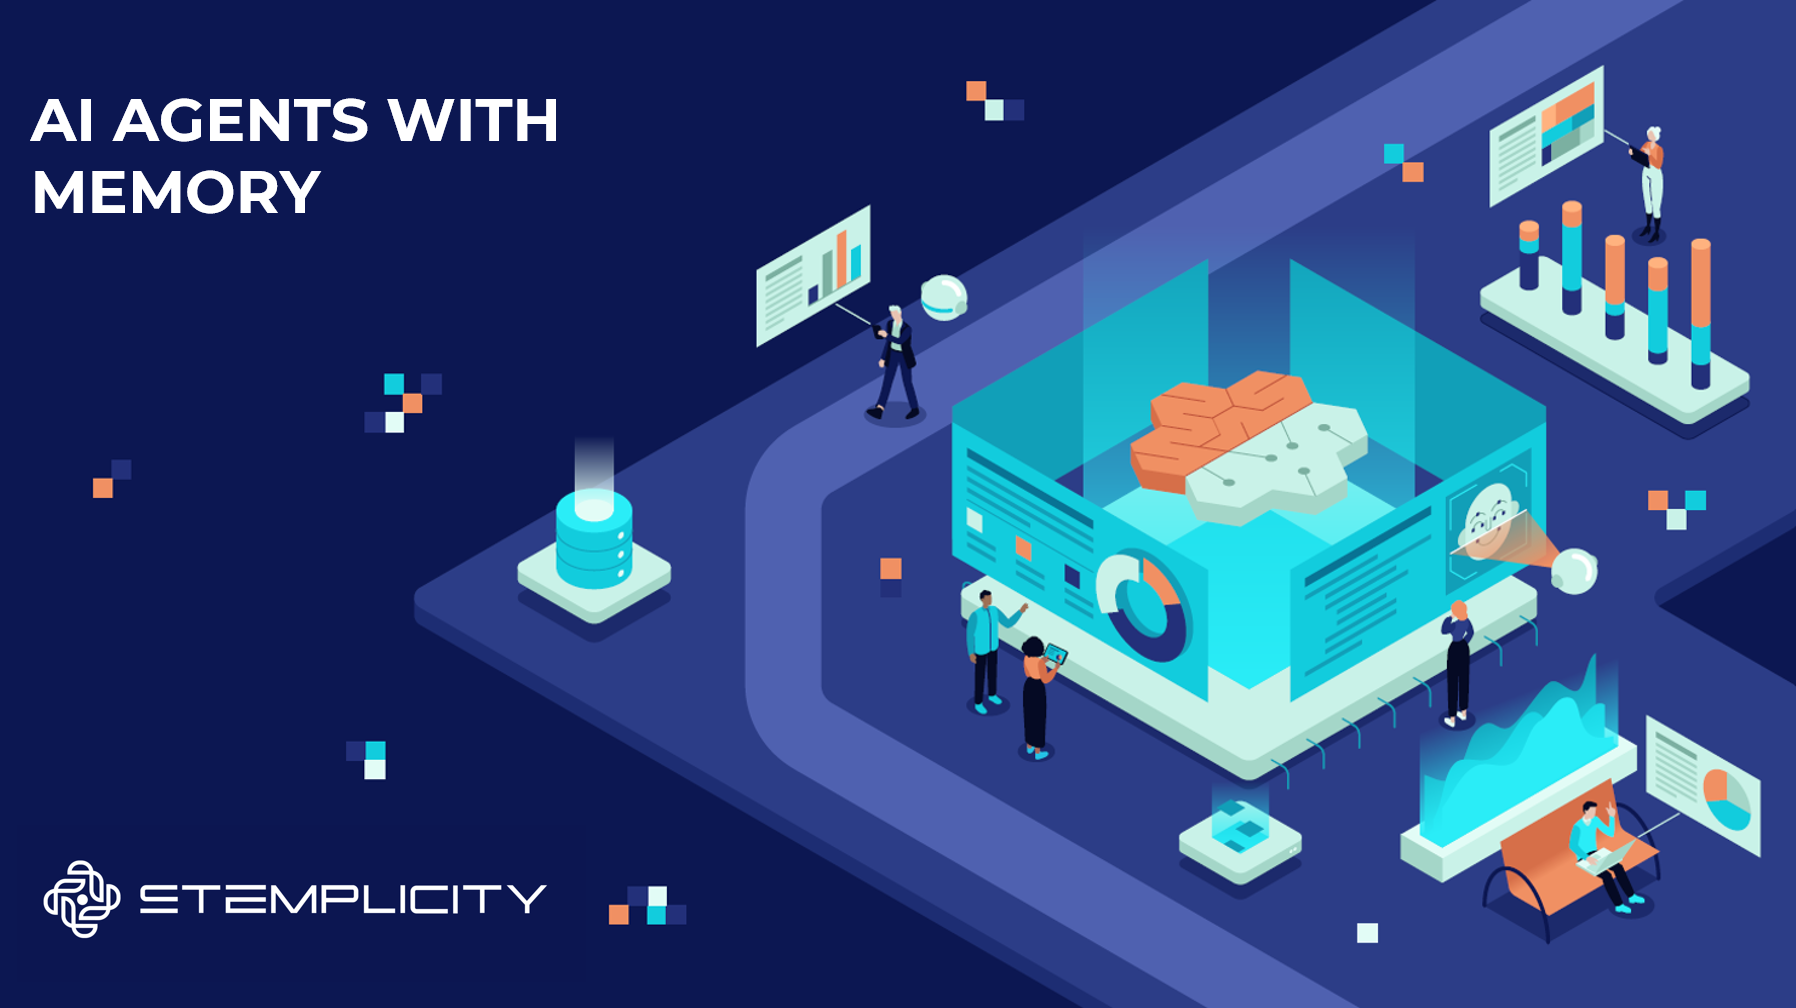

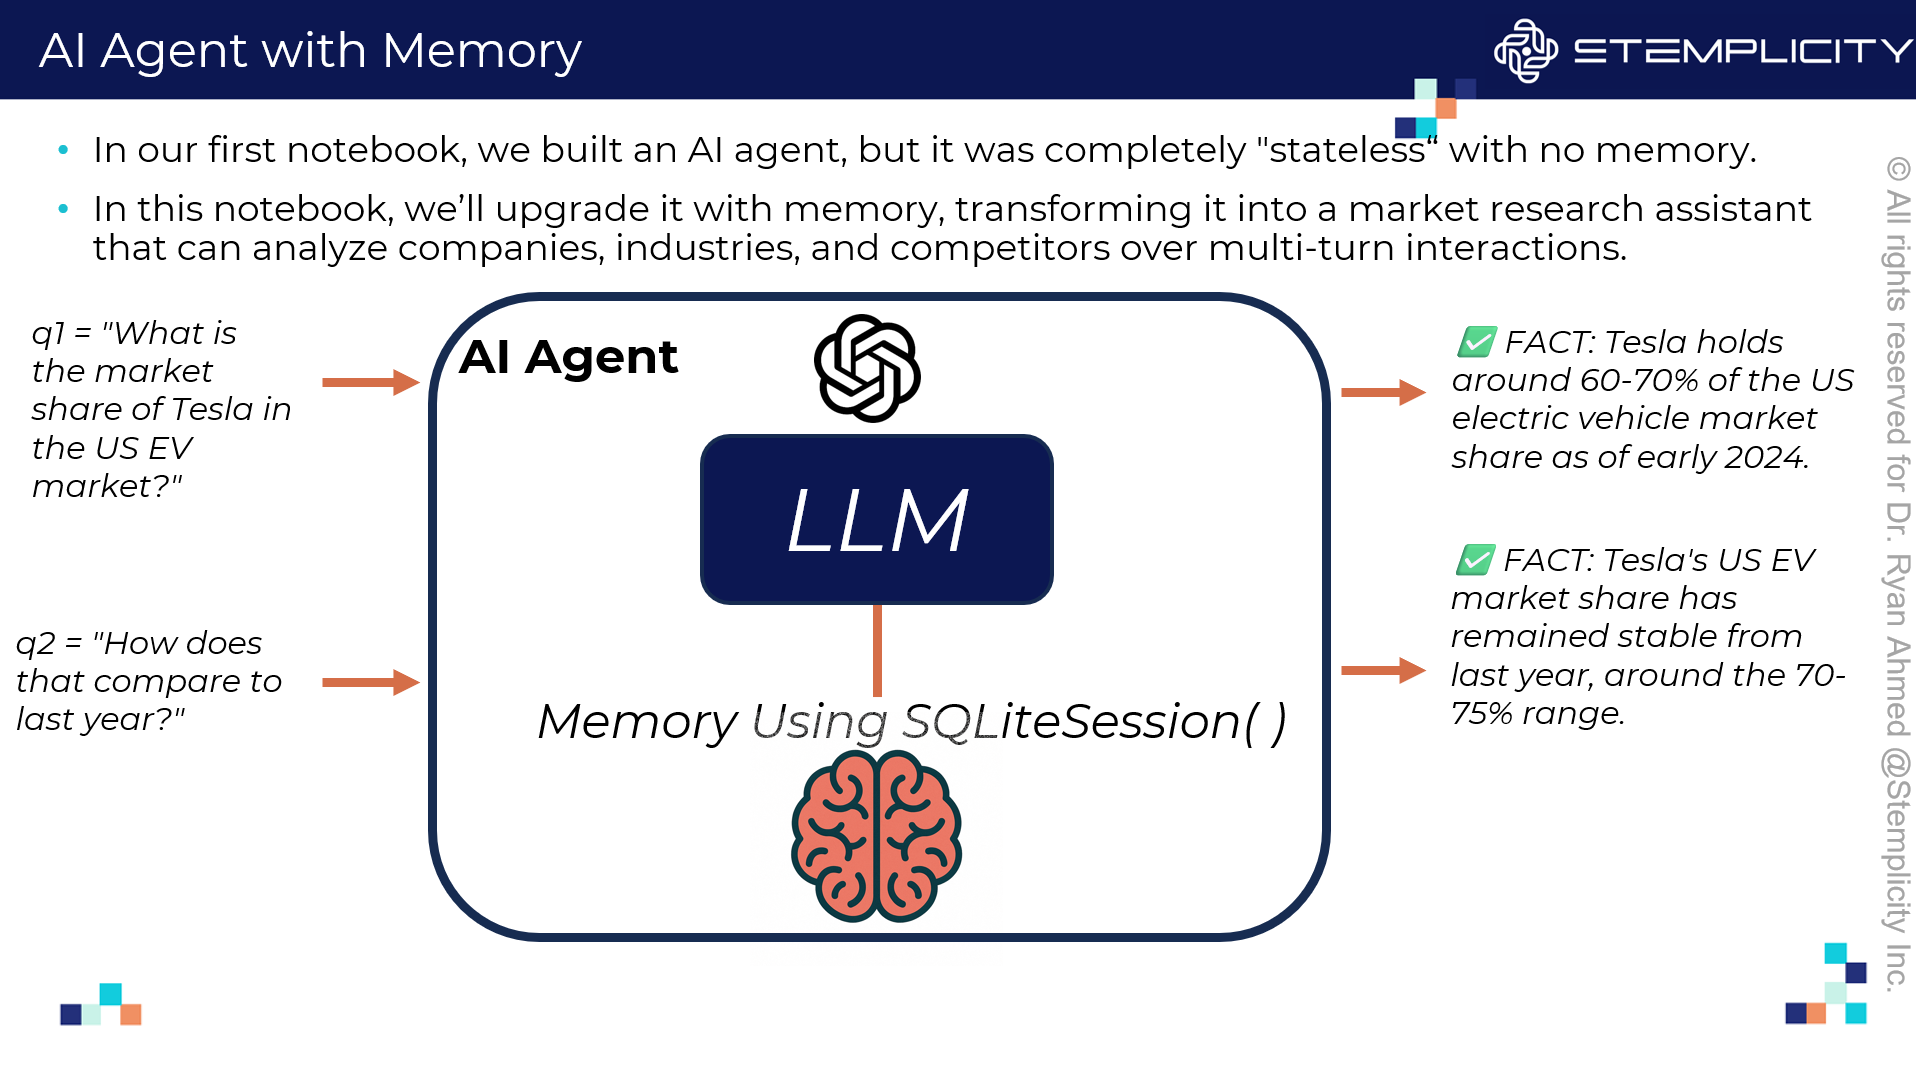

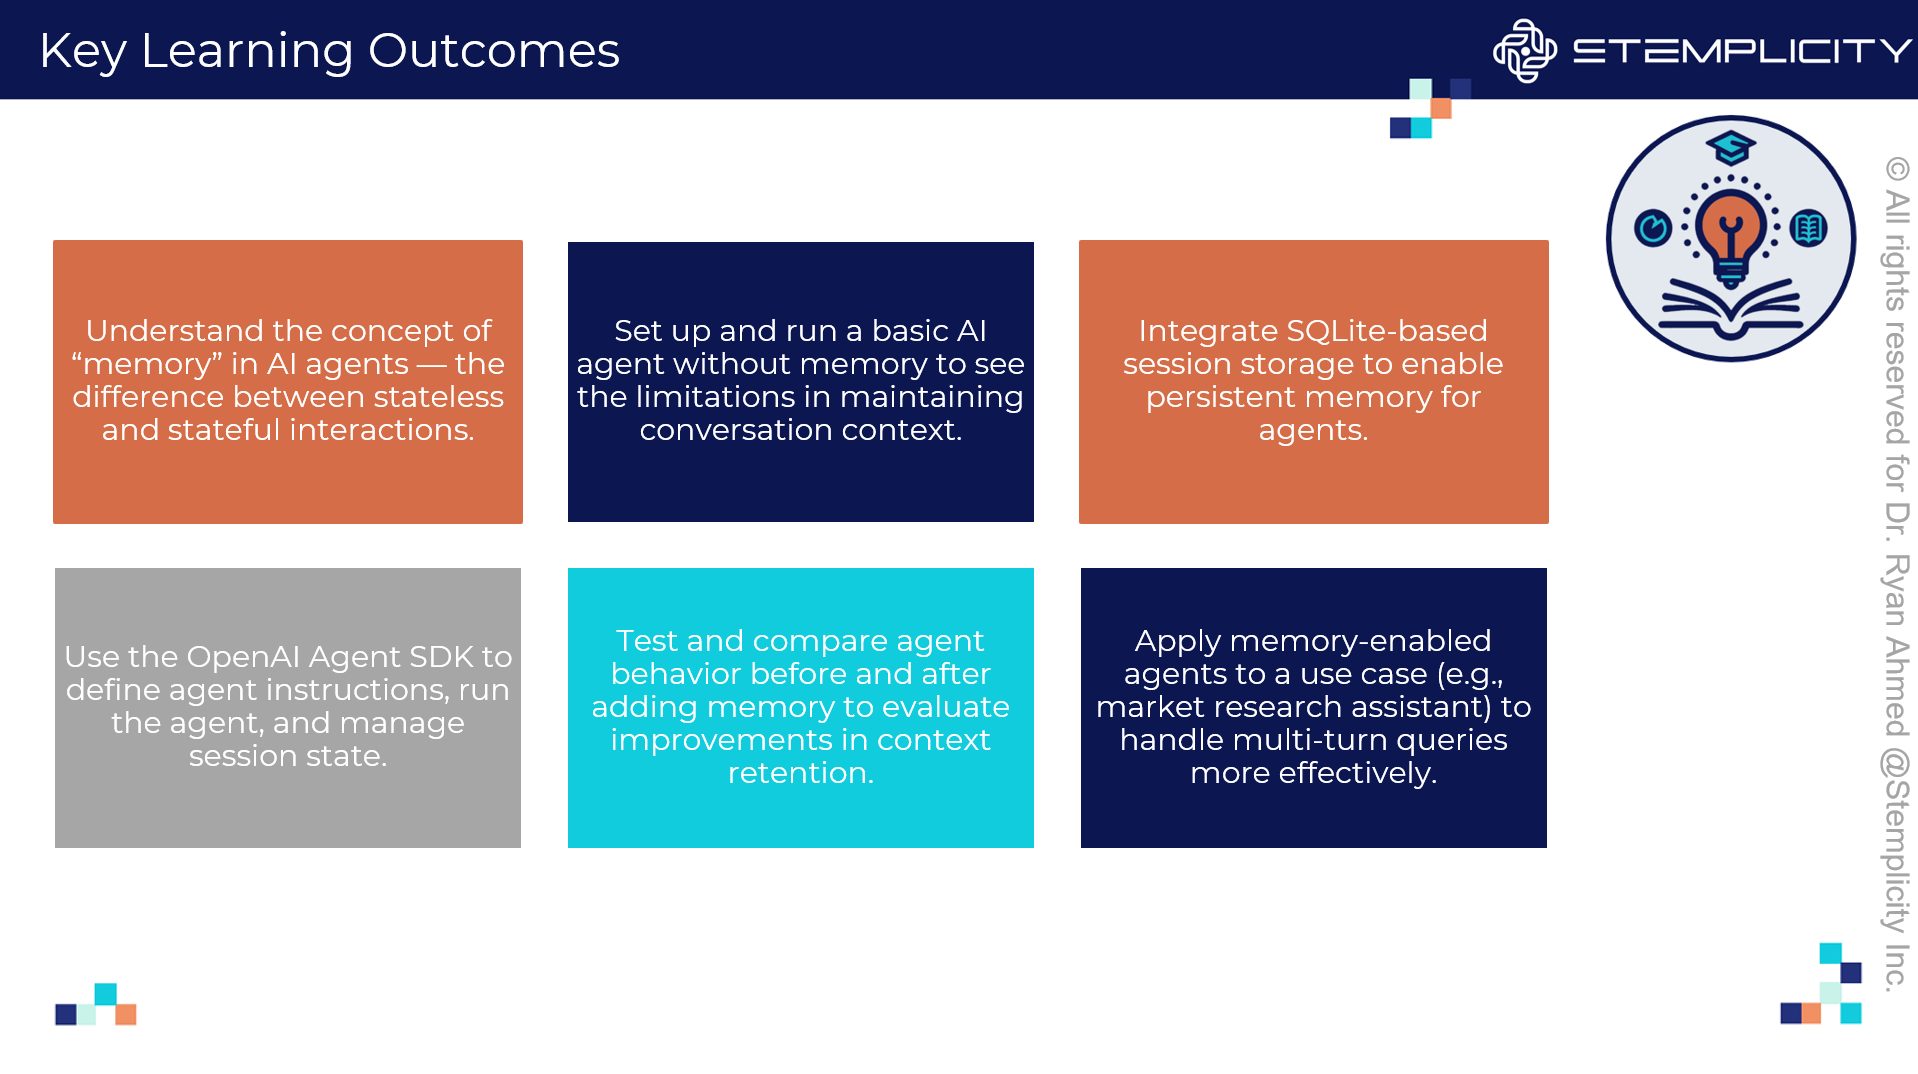

# TASK 2: SETTING UP YOUR ENVIRONMENT & BUILD AN AGENT WITH NO MEMORY


In [15]:
import os
import asyncio
from openai import AsyncOpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown
from agents import set_default_openai_client, set_default_openai_api, set_tracing_disabled

# Load environment variables and configure client
load_dotenv()

openrouter_api_key = os.getenv("OPENROUTER_API_KEY")

# 1. Create a custom async client pointing to OpenRouter
or_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=openrouter_api_key
)
    
# 2. Inject it into the Agents SDK
set_default_openai_client(or_client)
    
# 3. CRITICAL: Force the SDK to use Chat Completions 
# (OpenRouter does not support OpenAI's proprietary Responses API)
set_default_openai_api("chat_completions")

# 4. Disable telemetry to prevent the 401 error
set_tracing_disabled(True)

print("OpenAI client configured.")

OpenAI client configured.


In [3]:
# Define a function for printing markdown cells
def print_markdown(text):
    display(Markdown(text))

In [16]:
# Import required classes from the agents module
# Agent: Represents an AI agent with a specific role and instructions
# Runner: Executes the agent and handles interactions
# SQLiteSession: Provides persistent memory storage for the agent using SQLite

from agents import Agent, Runner, SQLiteSession

# Define the role and instructions for the AI agent
market_researcher_instructions = """
Context:
You are a market research assistant helping analyze companies, industries, and competitors.

Instructions:
When given a question, provide a short factual answer based on your knowledge.

Output:
Start with a verdict prefix: either "✅ FACT:" or "❌ UNKNOWN:"
Follow with a concise one-sentence explanation.
"""

# Create an instance of the Agent
market_researcher_agent = Agent(name = "Market Researcher",
                                instructions = market_researcher_instructions,
                                model = "nemotron-nano-9b-v2:free")

In [19]:
# Example: An AI Agent with NO memory

# Let's give our first question to the AI agent
q1 = "What is the market share of Tesla in the US EV market in 2022?"

# Display the user’s question in Markdown format
print_markdown(f"You: '{q1}'")

# Run the agent with the first question (no memory means each query is independent)
resp1 = await Runner.run(starting_agent = market_researcher_agent, input = q1)

# Display the agent’s response
print_markdown(f"🤖 Agent:\n{resp1.final_output}")

You: 'What is the market share of Tesla in the US EV market in 2022?'

🤖 Agent:
✅ FACT: Tesla's market share in the US EV market in 2022 was approximately 17%.


In [20]:
# Second question — depends on previous context
# Follow-up question that refers to the previous answer
q2 = "How does that compare to last year?"

# Display the follow-up question
print_markdown(f"\nYou: '{q2}'")

# Run the agent again — since there’s no memory, it does not recall the first question/answer
resp2 = await Runner.run(starting_agent = market_researcher_agent, input = q2)

# Display the agent’s response (will fail to connect it to the first question)
print_markdown(f"🤖 Agent:\n{resp2.final_output}")


You: 'How does that compare to last year?'

🤖 Agent:


❌ UNKNOWN: Unable to provide a comparison without specific details on what "that" refers to.


🛑 As expected, the agent has **no memory**.

# TASK 3: ADDING MEMORY WITH SQLITESESSION

In [21]:
# Create a session instance
# SQLite-based implementation of session storage.
# This implementation stores conversation history in a SQLite database. 

session = SQLiteSession("conversation")

# First interaction
user_input1 = "What is the market share of Tesla in the US EV market? in 2022"
response1 = await Runner.run(
    starting_agent = market_researcher_agent,
    input = user_input1,
    session = session,
)

print_markdown(f"🤖 Agent:\n{response1.final_output}")

🤖 Agent:


✅ FACT: Tesla held approximately 17.3% of the US EV market share in 2022, according to industry reports.


In [22]:
# Second interaction with history
user_input2 = "How does that compare to last year?"

response2 = await Runner.run(
    starting_agent = market_researcher_agent,
    input = user_input2,
    session = session,
) 

print_markdown(f"🤖 Agent:\n{response2.final_output}")

🤖 Agent:
✅ FACT: Tesla's US EV market share increased from 16.2% in 2021 to 17.3% in 2022, showing growth of over 1 percentage point.


✅ Success! Now the agent **remembers Tesla** because we provided the history ourselves.

**PRACTICE OPPORTUNITY:**  
- **Using OpenAI Agents SDK, create a new AI agent named `Travel Planner` that always suggests one sunny (warm) weekend getaway destination.**  
    - **1. Write the agent’s instructions; tell it to only give one sunny/warm destination.**  
    - **2. Use the latest `gpt-5-mini` model.**  
    - **3. Save the conversation history with `SQLiteSession` so it remembers past user questions and doesn’t repeat destinations.**  
    - **4. Ask the agent:**  
      **`Please suggest one weekend destination within 5 hours flying from Toronto, Canada`**  
    - **5. Display the agent’s answer.**  
    - **6. Then ask a follow-up question about visa requirements for Canadians for that destination and display the answer.**  
    - **Hint: Use `Runner.run()` to send the message to the agent and print the reply.**  

In [23]:
instruction = """
context:You are a travel planner having the idea of best global as well as local destinations which you can customize based on the time,
choice, region etc.

Instruction: Suggest one sunny/warm weekend gateway destination, given a user prompt.

Input: A user's prompt to suggest a weekend gateway.

Output: One weekend gateway destination.
"""

In [25]:
travel_agent_session = SQLiteSession("travel_agent")

travel_planning_agent = Agent(
    name = "Travel Planner",
    instructions= instruction,
    model="nemotron-nano-9b-v2:free"
)

In [29]:
response = await Runner.run(
    starting_agent= travel_planning_agent,
    input= "Please suggest one weekend destination within 5 hours flying from Toronto, Canada",
    session= travel_agent_session
)

print_markdown(f"🤖 Agent:\n{response.final_output}")

🤖 Agent:
**Suggested Weekend Gateway Destination: Orlando, Florida, USA**  
- **Why Orlando?**  
  - Located just **3.5 hours** from Toronto, it fits the 5-hour flight window.  
  - Consistently sunny and warm, especially in winter months.  
  - Offers a mix of beach relaxation (e.g., shores of Lake Eola or nearby coasts), theme parks (Universal Studios, Epcot), shopping, and family-friendly activities.  
  - Affordable accommodations and easy access to nearby nature reserves or historic towns like St. Augustine.  

This destination combines warmth, accessibility, and diverse experiences for a memorable weekend getaway! 🌞✨


In [30]:
followup_question = "What travel arrangements I should make before planning this excursion."

response2 = await Runner.run(
    starting_agent=travel_planning_agent,
    input = followup_question,
    session = travel_agent_session
)

print_markdown(response2.final_output)

Before planning your Orlando weekend excursion from Toronto, here are key **travel arrangements** to prioritize:  

---

### 1. **Booking Flights**  
   - **Compare airlines** (e.g., Air Canada, American Airlines, Delta) for the shortest flight time (~2.5–3.5 hours).  
   - **Flexible dates**: Look for weekend departures ( Fridays/Saturdays) to avoid peak pricing.  
   - **Book early** for better deals, especially during high-demand seasons (e.g., holidays, summer).  

---

### 2. **Accommodations**  
   - **Choose a base**: Stay near Orlando International Airport (for ease) or theme parks (e.g., Universal’s CityWalk).  
   - **Budget options**: Hotels like The Edison or Fairfield Inn, or vacation rentals via Airbnb.  
   - **Book in advance**: Especially if traveling during peak tourist season (spring/summer).  

---

### 3. **Transportation in Orlando**  
   - **Rent a car**: Recommended for flexibility to visit theme parks, beaches (e.g., Universal’s drive-in, or nearby Orlando Beach).  
   - **Public transit**: Use local buses (LYNX) or rideshare apps (Uber/Lyft) if you prefer not to drive.  

---

### 4. **Budgeting**  
   - Estimate costs:  
     - Flights: $300–$600 Round-trip (Toronto to Orlando).  
     - Lodging: $150–$300/night.  
     - Activities: Theme parks ($90–$150/person) or free/stroll-friendly attractions.  
   - Allocate extra for dining, shopping, and souvenirs.  

---

### 5. **Travel Insurance**  
   - Optional but recommended: Coverage for trip cancellations, medical emergencies, or flight delays.  

---

### 6. **Visa/Documents**  
   - Canadians need a **valid passport** (no visa required for short stays). Ensure your passport covers your travel dates.  

---

### 7. **Health & Safety Prep**  
   - Check Orlando’s weather forecast closer to your dates.  
   - Pack sunscreen, comfortable shoes, and a reusable water bottle.  
   - Confirm any health advisories (e.g., allergies, local outbreaks).  

---

### 8. **Local Customs**  
   - Orlando has a warm climate, but evenings can be cool in winter.  
   - Research park hours or special events (e.g., festivals) happening during your visit.  

Once these are secured, you can finalize your itinerary and enjoy a hassle-free trip! 🌴✈️


# PRACTICE OPPORTUNITY SOLUTIONS

**PRACTICE OPPORTUNITY SOLUTION:**  
- **Using OpenAI Agents SDK, create a new AI agent named `Travel Planner` that always suggests one sunny (warm) weekend getaway destination.**  
    - **1. Write the agent’s instructions; tell it to only give one sunny/warm destination.**  
    - **2. Use the latest `gpt-5-mini` model.**  
    - **3. Save the conversation history with `SQLiteSession` so it remembers past user questions and doesn’t repeat destinations.**  
    - **4. Ask the agent:**  
      **`Please suggest one weekend destination within 5 hours flying from Toronto, Canada`**  
    - **5. Display the agent’s answer.**  
    - **6. Then ask a follow-up question about visa requirements for Canadians for that destination and display the answer.**  
    - **Hint: Use `Runner.run()` to send the message to the agent and print the reply.**  

In [ ]:
from agents import Agent, Runner, SQLiteSession

travel_planner_instructions = """You are an assistant specializing in weekend travel planning.
Always suggest exactly ONE sunny (warm) destination for a quick getaway.
"""

In [ ]:
# Define agent
travel_planner_agent = Agent(name = "Travel Planner",
                             instructions = travel_planner_instructions,
                             model = "gpt-5-mini")

In [ ]:
session = SQLiteSession("travel_planner_session")

travel_msg = """Please suggest one weekend destination within 5 hours flying from Toronto, Canada"""

resp1_travel = await Runner.run(starting_agent = travel_planner_agent,
                                         input = travel_msg,
                                         session = session)

print_markdown(f"Travel Planner:\n{resp1_travel.final_output}")


In [ ]:
followup_travel = "What are the visa requirements for Canadians to this destination?"

resp2_travel = await Runner.run(
    starting_agent = travel_planner_agent,
    input = followup_travel,
    session = session
)

print_markdown(f"Travel Planner:\n{resp2_travel.final_output}")

- **Would love to connect with everyone on LinkedIn: www.linkedin.com/in/dr-ryan-ahmed**

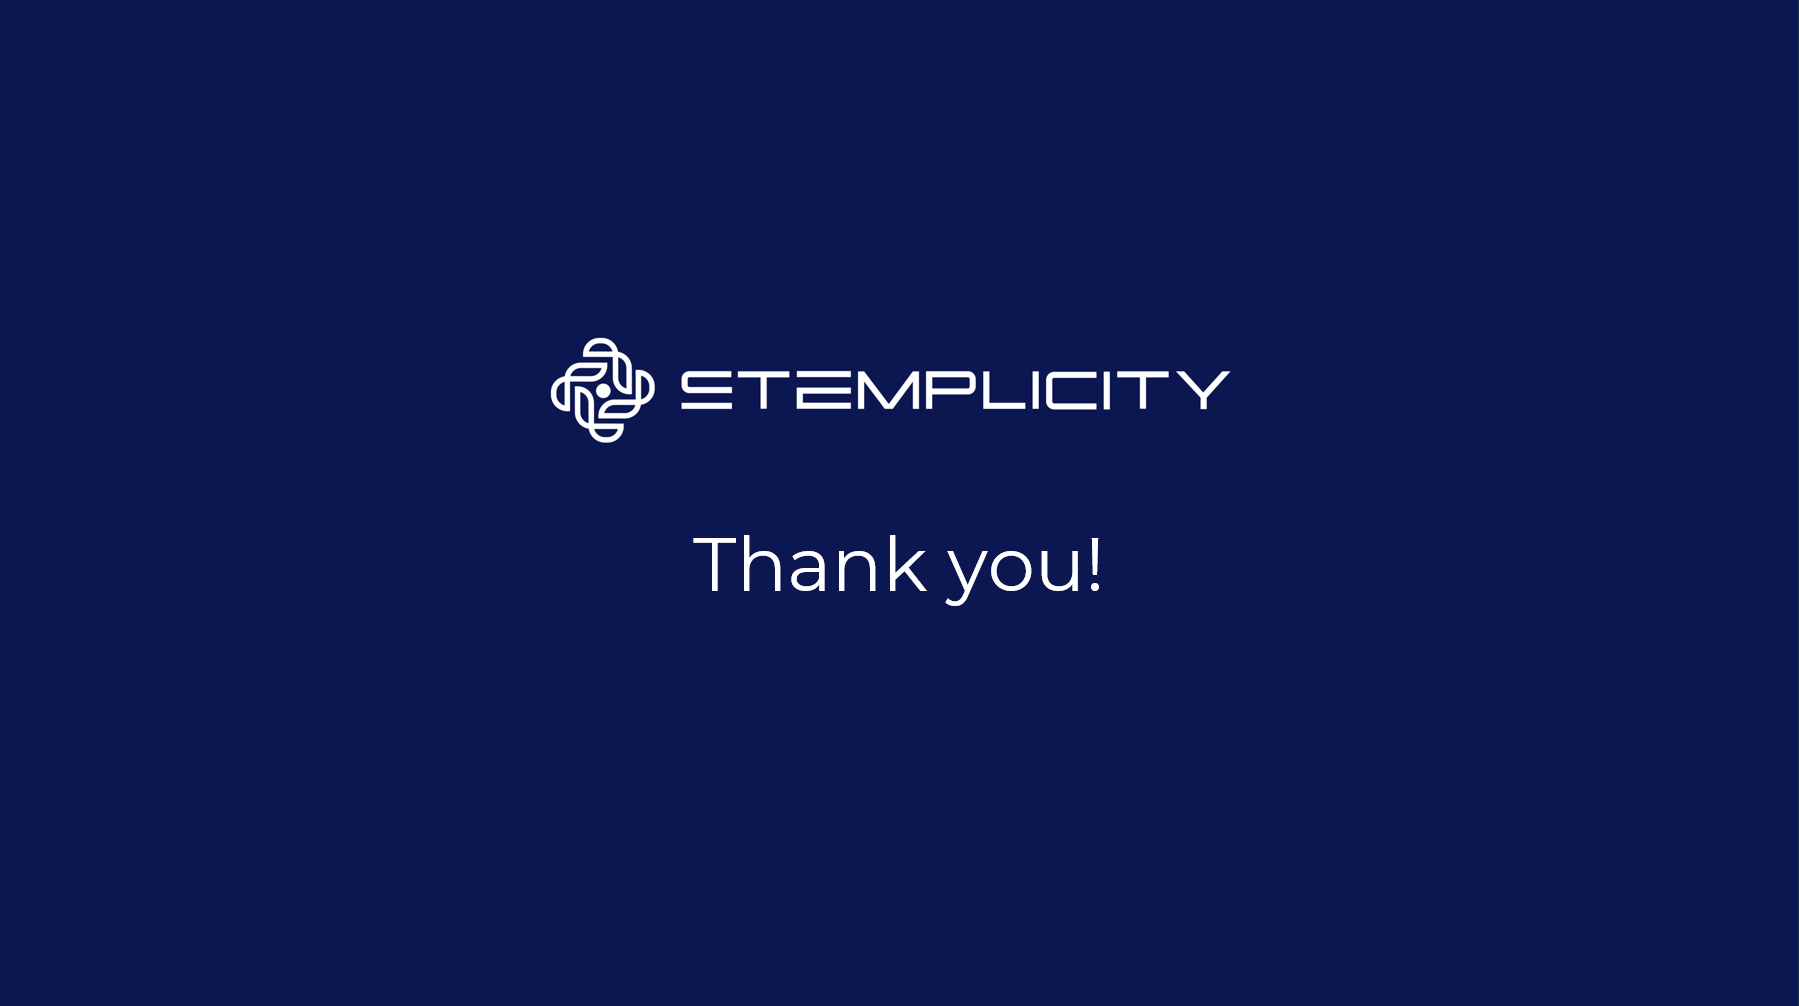